In [ ]:
from google.colab import files
uploaded = files.upload()

Saving brain_tumor_dataset.zip to brain_tumor_dataset (1).zip


In [ ]:
!unzip brain_tumor_dataset.zip

Archive:  brain_tumor_dataset.zip
replace brain_tumor_dataset/no/1 no.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: brain_tumor_dataset/no/1 no.jpeg  
replace brain_tumor_dataset/no/10 no.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: brain_tumor_dataset/no/10 no.jpg  
replace brain_tumor_dataset/no/11 no.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: brain_tumor_dataset/no/11 no.jpg  
replace brain_tumor_dataset/no/12 no.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: brain_tumor_dataset/no/12 no.jpg  
replace brain_tumor_dataset/no/13 no.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: brain_tumor_dataset/no/13 no.jpg  
replace brain_tumor_dataset/no/14 no.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: brain_tumor_dataset/no/14 no.jpg  
replace brain_tumor_dataset/no/15 no.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: brain_tumor_dataset/no/15 no.jpg  
replace brain_tumor_dataset/no/17 no.jpg? [y]es, [n]o, [

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    'brain_tumor_dataset/',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    'brain_tumor_dataset/',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [ ]:
model = models.Sequential()

# Conv Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten
model.add(layers.Flatten())

# Dense Layers
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))  # binary classification

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.6059 - loss: 0.9454 - val_accuracy: 0.6800 - val_loss: 0.6376
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.7980 - loss: 0.5336 - val_accuracy: 0.7400 - val_loss: 0.5356
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.8276 - loss: 0.4481 - val_accuracy: 0.7600 - val_loss: 0.5417
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.8325 - loss: 0.4001 - val_accuracy: 0.7400 - val_loss: 0.5340
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.8522 - loss: 0.3503 - val_accuracy: 0.7400 - val_loss: 0.4663
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.8571 - loss: 0.3201 - val_accuracy: 0.8000 - val_loss: 0.4304
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.9064 - loss: 0.2158 - val_accuracy: 0.8400 - val_loss: 0.4786
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.9360 - loss: 0.1316 - val_accuracy: 0.7800 - val_loss: 0.7300
Epoch 9/

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

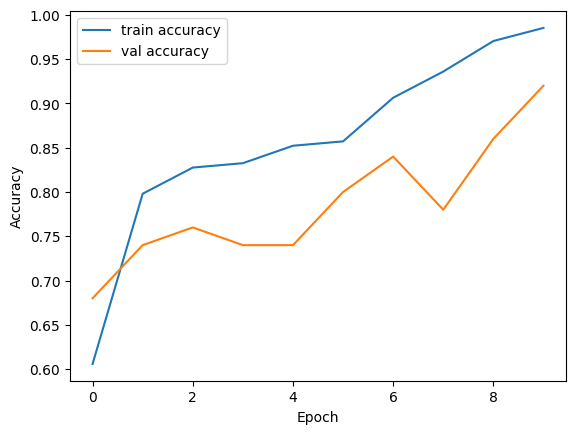

In [ ]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
from tensorflow.keras import Model # Add this import
import tensorflow as tf # Ensure tf is imported

def get_gradcam(model, img_array, layer_name='conv3_last'):
    # Ensure the model is built before accessing its input/output attributes
    if not model.built:
        model.build(input_shape=(None,) + img_array.shape[1:])

    # Explicitly call the model with a dummy input to ensure its input/output tensors are fully resolved
    # This is a common workaround for Sequential models when using their inputs/outputs in functional API constructs.
    _ = model(tf.zeros(img_array.shape))

    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]

    grads       = tape.gradient(loss, conv_out)
    pooled      = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap     = tf.nn.relu(conv_out[0] @ pooled[..., tf.newaxis])
    heatmap     = heatmap.numpy().squeeze()
    heatmap     = heatmap / (heatmap.max() + 1e-8)
    return heatmap

print('Grad-CAM function ready')

Grad-CAM function ready


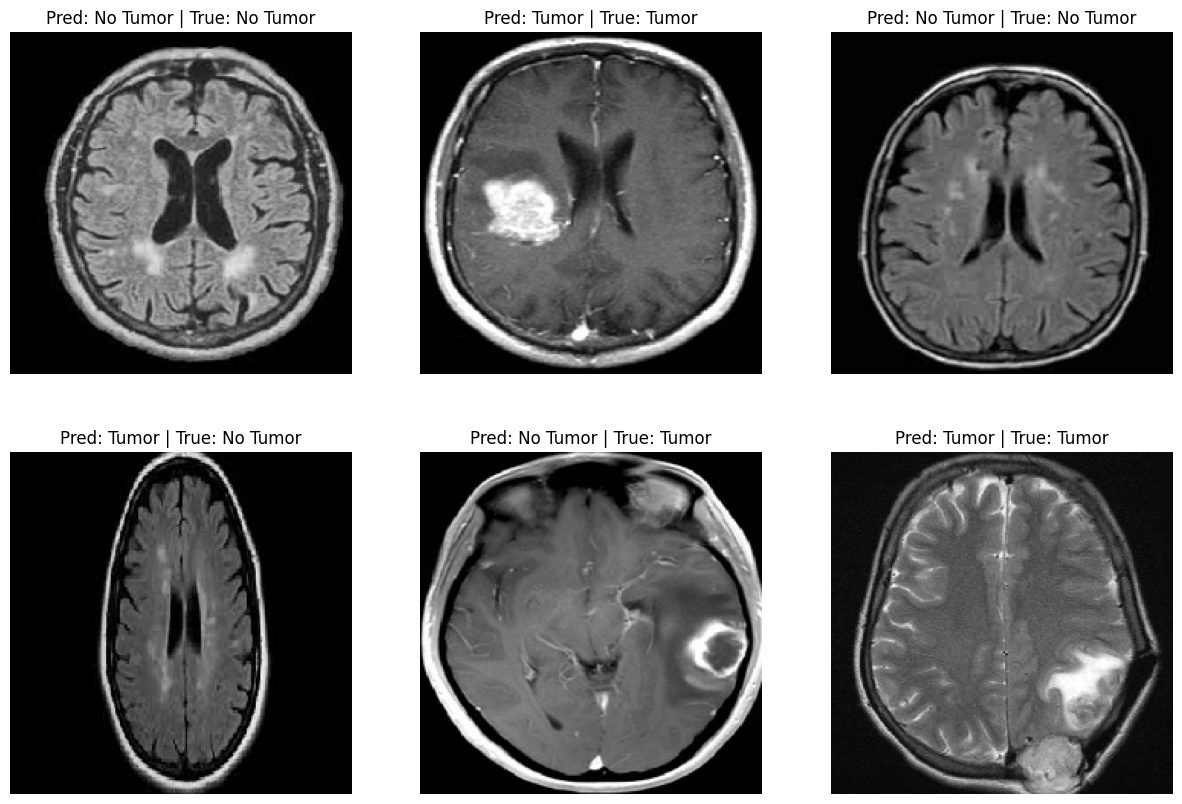

In [ ]:
import numpy as np # Import numpy

CLASS_NAMES = ['No Tumor', 'Tumor']

plt.figure(figsize=(15,10))

# Get a batch of images and labels from the validation data
imgs, labels = next(iter(val_data))

# Ensure we don't try to plot more images than available in the batch
num_images_to_plot = min(6, len(imgs))

for i in range(num_images_to_plot):
    img = imgs[i]
    inp = np.expand_dims(img, 0)

    prob = model.predict(inp, verbose=0)[0][0]
    pred = 'Tumor' if prob >= 0.5 else 'No Tumor'

    # safe handling
    label_value = int(labels[i])
    if label_value < len(CLASS_NAMES):
        true = CLASS_NAMES[label_value]
    else:
        true = "Unknown" # Fallback if label_value is out of bounds

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Pred: {pred} | True: {true}")
    plt.axis('off')

plt.show()